In [47]:
from lorenzo_utils import *
from visualization_utils import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import networkx as nx
np.random.seed(42)
graph_path = DATA_DIR + 'Centrality/Centrality_climate_19.graphml'
G = load_graph(graph_path)

c:\Users\maria\Desktop\Analisi e visualizzazione reti complesse\AVRC_FinnishTwittersphereProject\Maru\lorenzo_utils.py:24: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. Location: src/io/graphml.c:434
  return ig.Graph.Read_GraphML(filename)


In [48]:
def barra_avanzamento(progresso, totale):
    lunghezza_barra = 40
    percentuale = progresso / float(totale)
    riempimento = int(lunghezza_barra * percentuale)
    barra = '█' * riempimento + '-' * (lunghezza_barra - riempimento)
    
    # \r riporta il cursore all'inizio della riga per sovrascriverla
    sys.stdout.write(f'\rAvanzamento: |{barra}| {percentuale * 100:.1f}% completo')
    sys.stdout.flush()

Genero i due sottografi

In [49]:
nodi_A = G.vs.select(group="A")
G_A = G.subgraph(nodi_A)
nodi_B = G.vs.select(group="B")
G_B = G.subgraph(nodi_B)

# Statistica del network

In [68]:
def network_statistics(G):
    N = G.vcount()
    L = G.ecount()
    rho = G.density()
    avg_degree = 2 * L / N
    avg_clustering = G.transitivity_avglocal_undirected() # coefficiente di clustering medio
    diametro = G.diameter() # diametro del grafo


    return {
        "Numero di Nodi": N,
        "Numero di Archi": L,
        "Densità del Grafo": rho,
        "Grado Medio": avg_degree,
        "Clustering Medio": avg_clustering,
        "Diametro": diametro 
    }


In [65]:
def communities_statistics(G):
    A = G.vs.select(group="A")
    B = G.vs.select(group="B")
    n_A = len(A)
    n_B = len(B)
    p = n_A / G.vcount()
    
    return n_A, n_B, p, 1-p, 2*p*(1-p)
    

In [66]:
def print_network_statistics(G):
    stat = network_statistics(G)
    print("        STATISTICHE DEL NETWORK        ")
    print("-"*40)
    for key, value in stat.items():
        print(f"{key}: {value}")
        
    print("-"*40)


In [20]:
print_network_statistics(G)

        STATISTICHE DEL NETWORK        
----------------------------------------
Numero di Nodi: 16639
Numero di Archi: 50605
Densità del Grafo: 0.0003655906525712596
Grado Medio: 6.082697277480618
Clustering Medio: 0.17544907339858107
Diametro: 13
----------------------------------------


In [21]:
stats_A = network_statistics(G_A)
stats_B = network_statistics(G_B)

print("SOTTOGRAFO A")
print_network_statistics(G_A)
print("\nSOTTOGRAFO B")
print_network_statistics(G_B)

SOTTOGRAFO A
        STATISTICHE DEL NETWORK        
----------------------------------------
Numero di Nodi: 7409
Numero di Archi: 28384
Densità del Grafo: 0.0010342916661686635
Grado Medio: 7.6620326629774596
Clustering Medio: 0.2572179272650303
Diametro: 12
----------------------------------------

SOTTOGRAFO B
        STATISTICHE DEL NETWORK        
----------------------------------------
Numero di Nodi: 9230
Numero di Archi: 17487
Densità del Grafo: 0.00041057165064618605
Grado Medio: 3.789165763813651
Clustering Medio: 0.12504484957300033
Diametro: 14
----------------------------------------


# Calcolo delle metriche e aggiornamento su file

In [22]:
COMPUTE_CENTRALITY = False
if COMPUTE_CENTRALITY:
    from sys import stdout
    for graph_file in GRAPH_FILENAMES:
        print('loading:', graph_file)
        stdout.flush()
        G = load_graph(DATA_DIR + graph_file)
        load_all_centralities(G, dumpfile=DATA_DIR+'Centrality/Centrality_'+graph_file)
        print('saved centrality')

# CCDF (Complementary cumulative distribution)

In [23]:
def plot_ccdf(G: ig.Graph, metric: str='degree', log: bool=True, save: bool=False):
    values = np.array(G.vs[metric])
    k_values, ccdf = compute_ccdf(values, xmin=0)
    kA_values, ccdfA = compute_ccdf(values[[group == 'A' for group in G.vs['group']]], xmin=0)
    kB_values, ccdfB = compute_ccdf(values[[group == 'B' for group in G.vs['group']]], xmin=0)

    fig, ax = plt.subplots(figsize=FIGSIZE, sharex=True, layout='tight')
    ax.plot(k_values, ccdf, marker='.', linewidth='2', markersize='0.3', color = 'black', alpha=0.7,label='Tot')
    ax.plot(kA_values, ccdfA, marker='.', linewidth='2', markersize='0.3', color = color_group['A'], label='A')
    ax.plot(kB_values, ccdfB, marker='.', linewidth='2', markersize='0.3', color = color_group['B'], label='B')
    ax.set_title(metric + ' complementary cumulative distribution')
    ax.set_xlabel(metric)
    ax.set_ylabel('ccdf')
    fig.legend(frameon=False, bbox_to_anchor=(0.99,0.9), loc='upper right')
    if log:
        ax.set_xscale('log')
        ax.set_yscale('log')
    if save:
        plt.savefig(f'ccdf_{metric}.png')    
    plt.show()    
    plt.close(fig)   

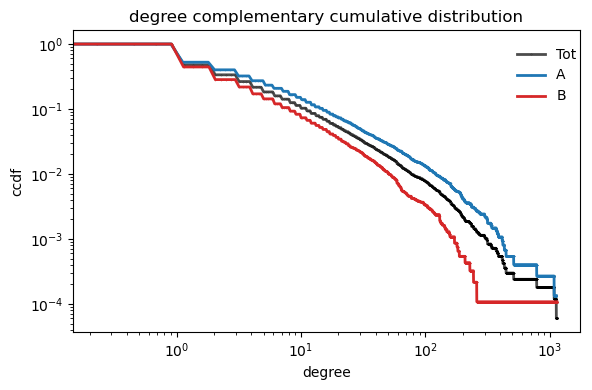

In [24]:
plot_ccdf(G, 'degree', log=True)

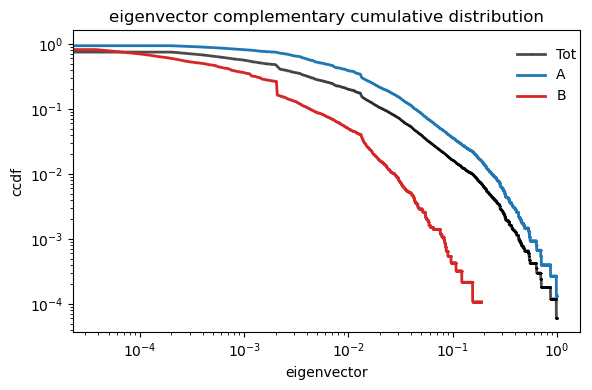

In [25]:
plot_ccdf(G, 'eigenvector', log=True)

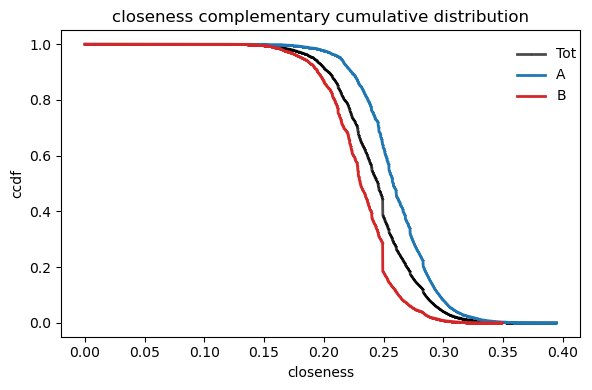

In [26]:
plot_ccdf(G, 'closeness', log=False)

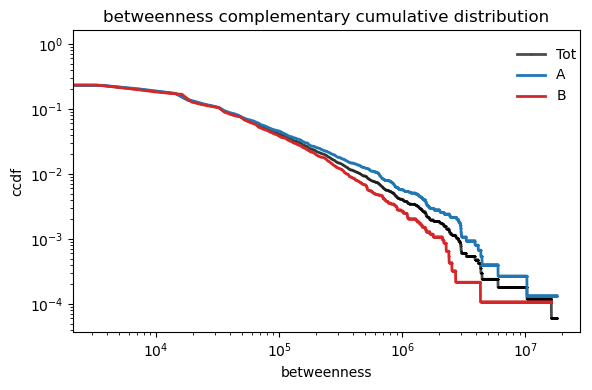

In [27]:
plot_ccdf(G, 'betweenness', log=True)

# Scatter plot

In [ ]:
def plot_metric_vs_metric(G, metric_x, metric_y, color=cmap(0)):
    fig, ax = plt.subplots(figsize=FIGSIZE, sharex=True, layout='tight')
    ax.scatter(G.vs[metric_x], G.vs[metric_y], s=0.3, color=color)
    ax.set_title(f'{metric_y} vs {metric_x}')
    ax.set_xlabel(metric_x)
    ax.set_ylabel(metric_y)
    ax.set_xscale('log')
    ax.set_yscale('log')
    plt.savefig(f'{metric_y}_vs_{metric_x}.png')
    plt.show()
    
    return fig, ax
    

In [ ]:
def plot_metric_vs_metric_AB(G, metric_x, metric_y, metric_size, ax, group=None):
    size_min, size_max = 4.8, 96
    if metric_size is not None:
        s = np.interp(G.vs[metric_size], (np.array(G.vs[metric_size]).min(), np.array(G.vs[metric_size]).max()), (size_min, size_max))
    else:
        s = 0.3
    ax.scatter(G.vs[metric_x], G.vs[metric_y], s=s, color=color_group[group], alpha=0.4, edgecolors='black', label=group)
    ax.set_title(f'{metric_y} vs {metric_x}')
    ax.set_xlabel(metric_x)
    ax.set_ylabel(metric_y)
    ax.legend()
    ax.set_xscale('log')
    ax.set_yscale('log')

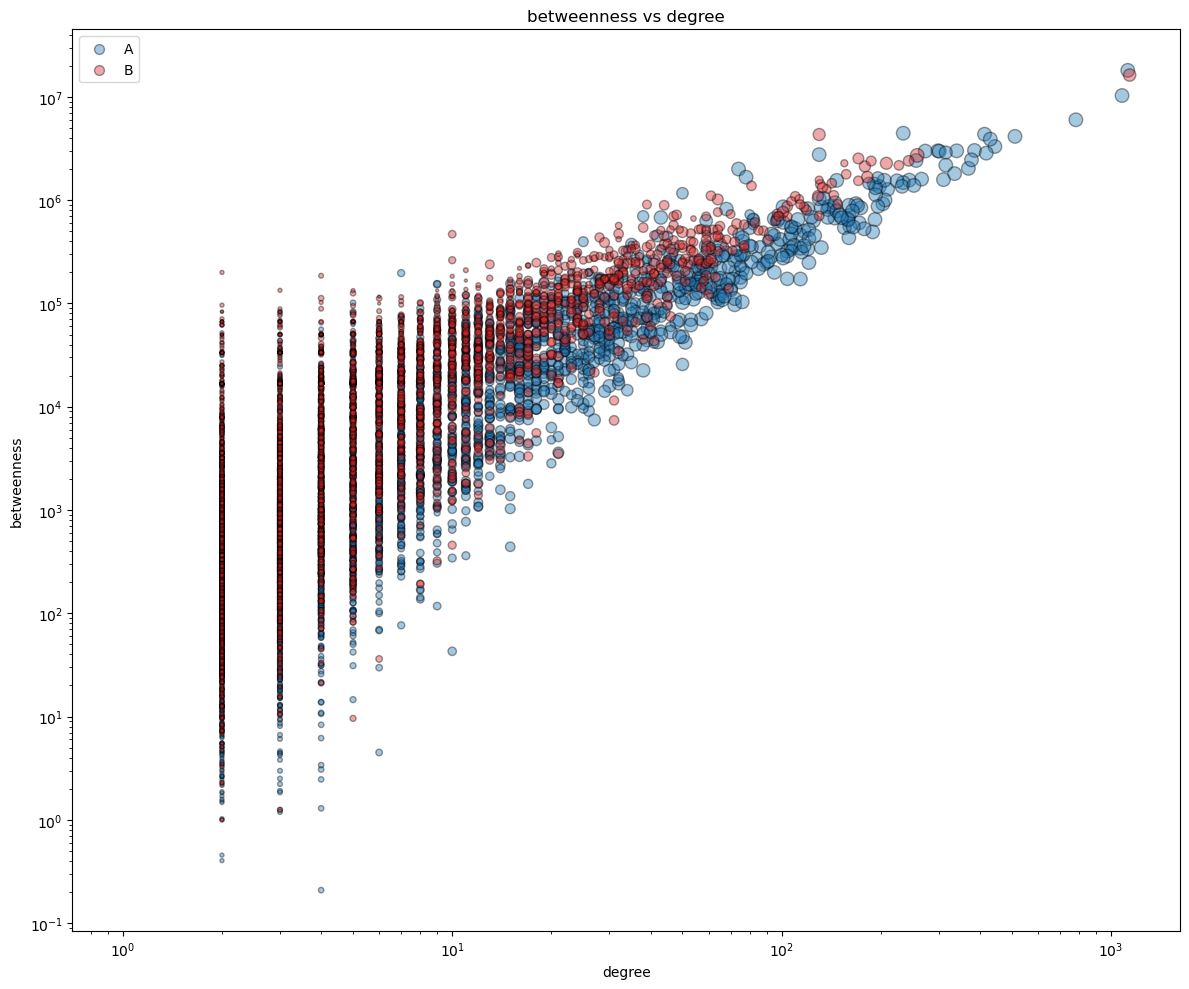

In [94]:

fig, ax = plt.subplots(figsize=FIGSIZE_LARGE, sharex=True, layout='tight')
plot_metric_vs_metric_AB(G_A, 'degree', 'betweenness', 'coreness', ax, group='A')
plot_metric_vs_metric_AB(G_B, 'degree', 'betweenness', 'coreness', ax, group='B')



# Distribuzioni di misure di centralità

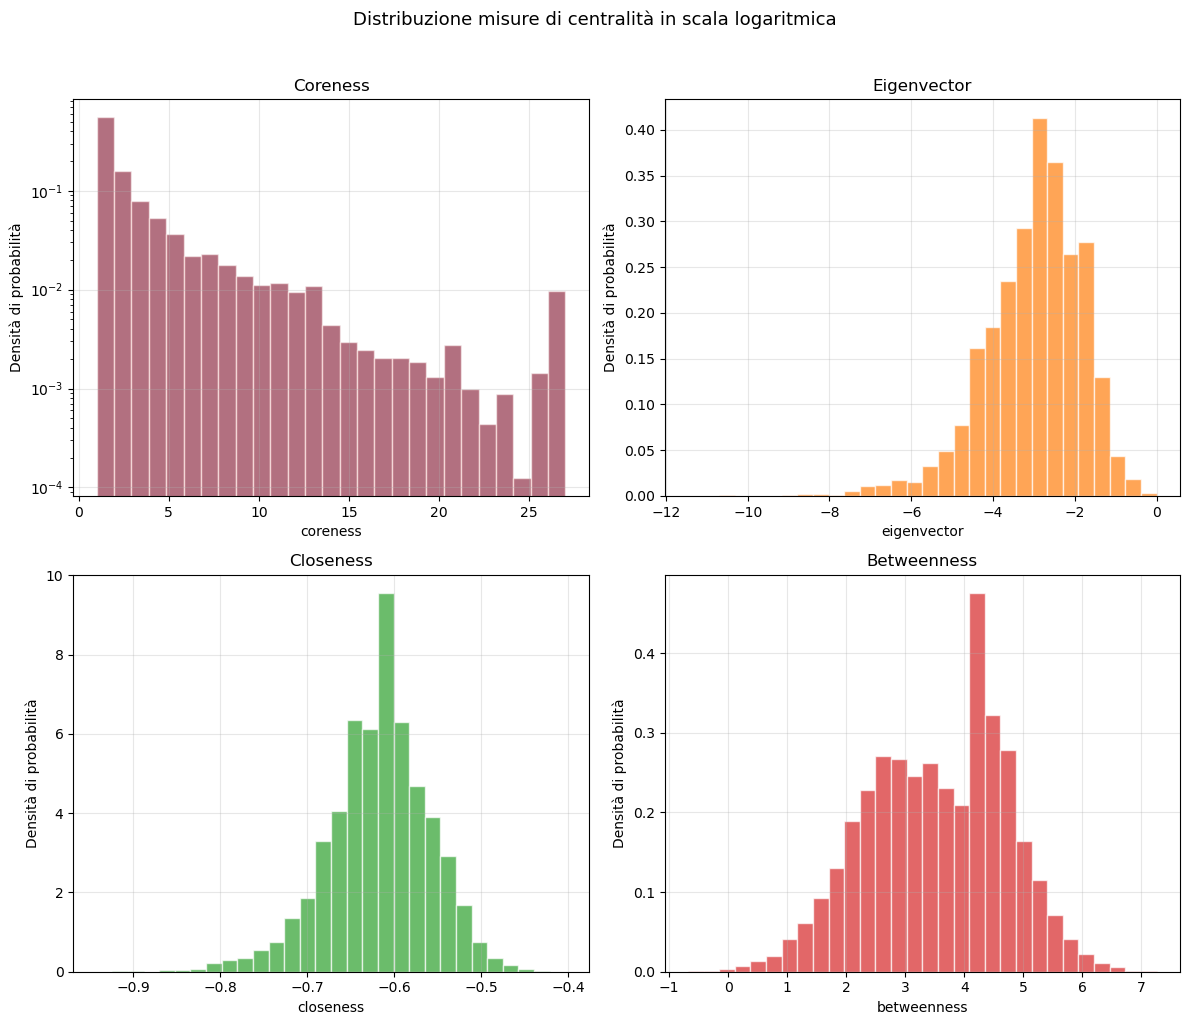

In [31]:
metrics = ['coreness', 'eigenvector', 'closeness', 'betweenness']
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_LARGE, layout='tight')
colors = [cmap(i) for i in range(len(metrics))]

for ax, m, color in zip(axes.flat, metrics, colors):
    
    values = np.array(G.vs[m], dtype=float)
    values = values[values > 0]

    if m == 'coreness':
        ax.hist(values, bins=27, density=True,
                color=cmap(0), alpha=0.5, edgecolor='white', label='A')
        ax.hist(values, bins=27, density=True,
                color=cmap(3), alpha=0.5, edgecolor='white', label='B')
        ax.set_yscale('log')
    else:    
        ax.hist(np.log10(values), bins=30, density=True,
                color=color, alpha=0.7, edgecolor='white')
    ax.set_title(m.capitalize())
    ax.set_xlabel(m)
    ax.set_ylabel("Densità di probabilità" )
    ax.grid(alpha=0.3)
    

fig.suptitle("Distribuzione misure di centralità in scala logaritmica", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
plt.close(fig)

Domanda:
sono gli stessi nodi a generare i picchi nei vari grafici?

In [6]:

def plot_centralities(G):
        metrics = ['coreness', 'eigenvector', 'closeness', 'betweenness']
        fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_LARGE)


        for ax, m in zip(axes.flat, metrics):
                values = np.array(G.vs[m], dtype=float)

                valuesA = np.array(values[[group == 'A' for group in G.vs['group']]])
                valuesB = np.array(values[[group == 'B' for group in G.vs['group']]])
                valuesA = valuesA[valuesA > 0]
                valuesB = valuesB[valuesB > 0]
                all_vals = np.concatenate([np.log10(valuesA), np.log10(valuesB)])
                bins = np.linspace(all_vals.min(), all_vals.max(), 40) 
                x_ticks_log = np.linspace(all_vals.min(), all_vals.max(), 6)
                x_ticks_original = 10 ** x_ticks_log  # valori originali corrispondenti

                if m == 'coreness':  # coreness è già in scala discreta, non ha senso logaritmizzarla
                        ax.hist(valuesA, bins=27, density=True,
                                color=color_group['A'], alpha=0.5, edgecolor='white', label='A')
                        ax.hist(valuesB, bins=27, density=True,
                                color=color_group['B'], alpha=0.5, edgecolor='white', label='B')
                        ax.set_yscale('log')

                else:
                        ax.hist(np.log10(valuesA), bins=bins, density=True,
                                color=color_group['A'], alpha=0.5, edgecolor='white', label='A')
                        ax.hist(np.log10(valuesB), bins=bins, density=True,
                                color=color_group['B'], alpha=0.5, edgecolor='white', label='B')
                        ax.set_xticks(np.linspace(all_vals.min(), all_vals.max(),6))
                        ax.set_xticklabels([f"$10^{{{v:.1f}}}$" for v in x_ticks_log])
                ax.set_title(m.capitalize())
                ax.tick_params(direction='out')
                
                ax.set_xlabel(m)
                ax.set_ylabel("Densità di probabilità")
                ax.grid(alpha=0.3)
                ax.legend()


        fig.savefig("centralities.png")
        fig.suptitle("Distribuzione misure", fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

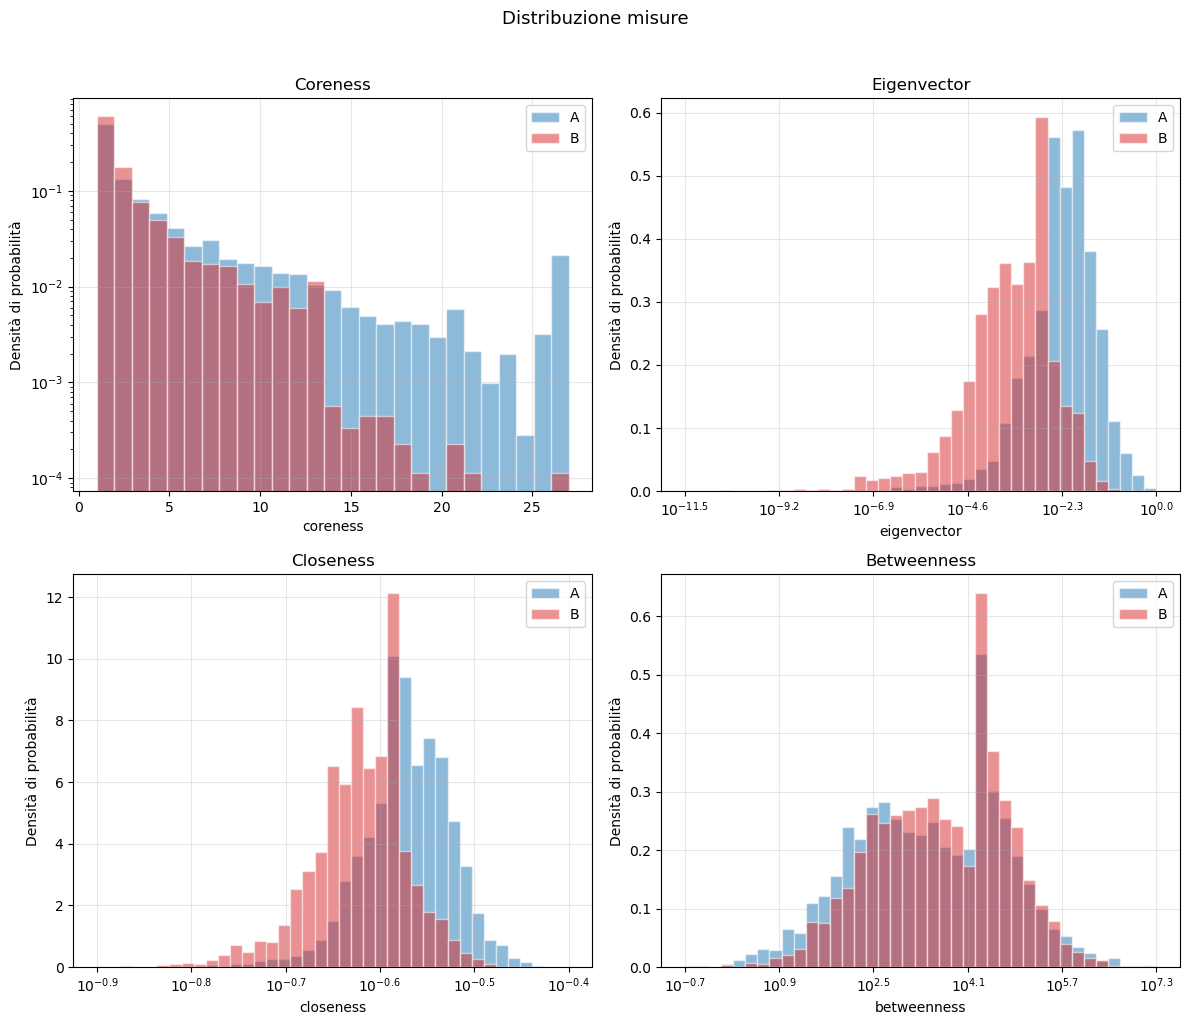

In [21]:
plot_centralities(G)

- **CORENESS** 
Il gruppo A domina i k-core alti (coreness 10–27), mentre B è quasi assente oltre il 15. Questo indica che A forma un nucleo densamente interconnesso, un "inner circle" di utenti che si ritwittano a vicenda intensamente. B invece è più periferico, con molti nodi a basso coreness. È un segnale classico di **echo chamber asimmetrica**: A ha una comunità più coesa e organizzata.
- **EIGENVECTOR**
B ha la distribuzione spostata verso sinistra (valori più negativi = centralità più bassa), A verso destra. Significa che i nodi di A sono connessi ad altri nodi influenti, mentre B ha nodi influenti più isolati o connessi a nodi periferici. In un grafo di retweet politico, questo può indicare che le figure chiave di A amplificano reciprocamente il loro messaggio più efficacemente.
- **CLOSENESS**
A è spostato verso destra (valori meno negativi = closeness più alta). I nodi di A raggiungono il resto del grafo in meno passi: sono meglio posizionati per diffondere informazioni a tutto il network. B ha closeness più bassa e più dispersa, suggerendo una struttura più frammentata.
- **BETWEENNESS**
Qui la differenza è più sottile, ma A tende ad avere betweenness leggermente più alta e con coda più lunga verso destra. Ci sono nodi di A che fungono da **broker o ponti** nella rete. Interessante: se ci sono nodi B con alta betweenness, potrebbero essere utenti che "attraversano" le due bolle (cross-cutting), vale la pena identificarli.

### Chi sono i nodi più importanti?

In [ ]:
def print_top_nodes(G: ig.Graph, metric='betweenness'):

    # 3. Associa l'ID del nodo (e il nome) al rispettivo valore di betweenness
    # Usiamo g.vs per iterare sui nodi ottenendo index, attributi e valore
    nodes_with_metric = [
        {"id": v.index, metric: b}
        for v, b in zip(G.vs, G.vs[metric])
    ]

    # 4. Ordina la lista in ordine decrescente in base alla betweenness e prendi i primi 10
    top_10_nodi = sorted(nodes_with_metric, key=lambda x: x[metric], reverse=True)[:10]
    print(f"{'Pos.':<5} {'ID Nodo':<10} {metric:<12}")
    print("-" * 40)
    for i, nodo in enumerate(top_10_nodi, 1):
        print(f"{i:<5} {nodo['id']:<10}  {nodo[metric]:.2f}")

In [120]:
for metric in ['degree','betweenness']:
    print_top_nodes(G, metric)

Pos.  ID Nodo    degree      
---------------------------------------------
1     4785        1139.00
2     227         1124.00
3     64          1080.00
4     84          782.00
5     35          511.00
6     104         444.00
7     126         430.00
8     995         418.00
9     96          413.00
10    32          385.00
Pos.  ID Nodo    betweenness 
---------------------------------------------
1     227         18059280.88
2     4785        16252601.58
3     64          10297172.98
4     84          5994290.77
5     2           4445923.51
6     96          4348075.46
7     7294        4315253.90
8     35          4139846.59
9     126         3897377.99
10    104         3308032.12


In [121]:
for metric in ['closeness', 'eigenvector']:
    print_top_nodes(G, metric)

Pos.  ID Nodo    closeness   
---------------------------------------------
1     227         0.39
2     64          0.37
3     96          0.37
4     84          0.37
5     2           0.37
6     35          0.36
7     3           0.36
8     32          0.36
9     417         0.36
10    88          0.36
Pos.  ID Nodo    eigenvector 
---------------------------------------------
1     64          1.00
2     227         0.99
3     84          0.87
4     35          0.71
5     96          0.70
6     32          0.64
7     88          0.63
8     211         0.55
9     3           0.54
10    995         0.54


## Degree distribution

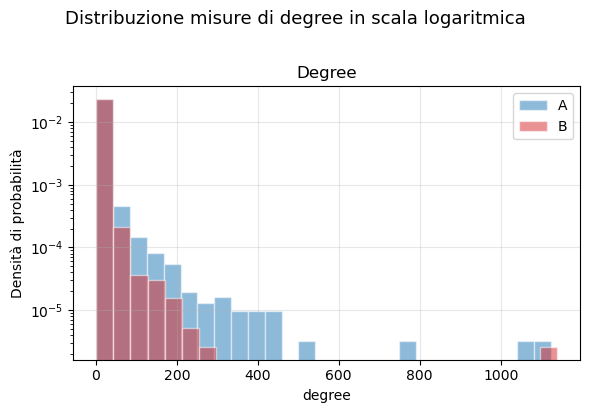

In [33]:
m = 'degree'
fig, ax = plt.subplots(figsize=FIGSIZE)

values = np.array(G.vs[m], dtype=float)
valuesA = np.array(values[[group == 'A' for group in G.vs['group']]])
valuesB = np.array(values[[group == 'B' for group in G.vs['group']]])
valuesA = valuesA[valuesA > 0]
valuesB = valuesB[valuesB > 0]


ax.hist(valuesA, bins=27, density=True,
        color=color_group['A'], alpha=0.5, edgecolor='white', label='A')
ax.hist(valuesB, bins=27, density=True,
        color=color_group['B'], alpha=0.5, edgecolor='white', label='B')
ax.set_yscale('log')

ax.set_title(m.capitalize())
ax.set_xlabel(m)
ax.set_ylabel("Densità di probabilità")
ax.grid(alpha=0.3)
ax.legend()

fig.suptitle(f"Distribuzione misure di {m} in scala logaritmica", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{m}_distribution.png')
plt.show()

plt.close(fig)

# Coreness

In [58]:
G.vs['coreness'] = G.coreness()

In [59]:
max_coreness = max(G.vs['coreness'])
nodes_in_max_core = G.vs.select(coreness_ge=max_coreness)
main_core = G.subgraph(nodes_in_max_core)
print(f"Il core massimo ha k = {max_coreness} e contiene {main_core.vcount()} nodi.")

Il core massimo ha k = 27 e contiene 155 nodi.


In [120]:
def subgraph_core(G, K_core, plot=True):
    nodes_in_core = G.vs.select(coreness_ge=K_core)
    subgraph_core = G.subgraph(nodes_in_core)
    #print(f"Il core ha k = {K_core} e contiene {subgraph_core.vcount()} nodi.")
    if plot:
        plot_group_AB(subgraph_core, save=False, only_periphery=False, niter=None)
        plt.show()
        
    return subgraph_core    

Gruppi trovati: ['A', 'B']


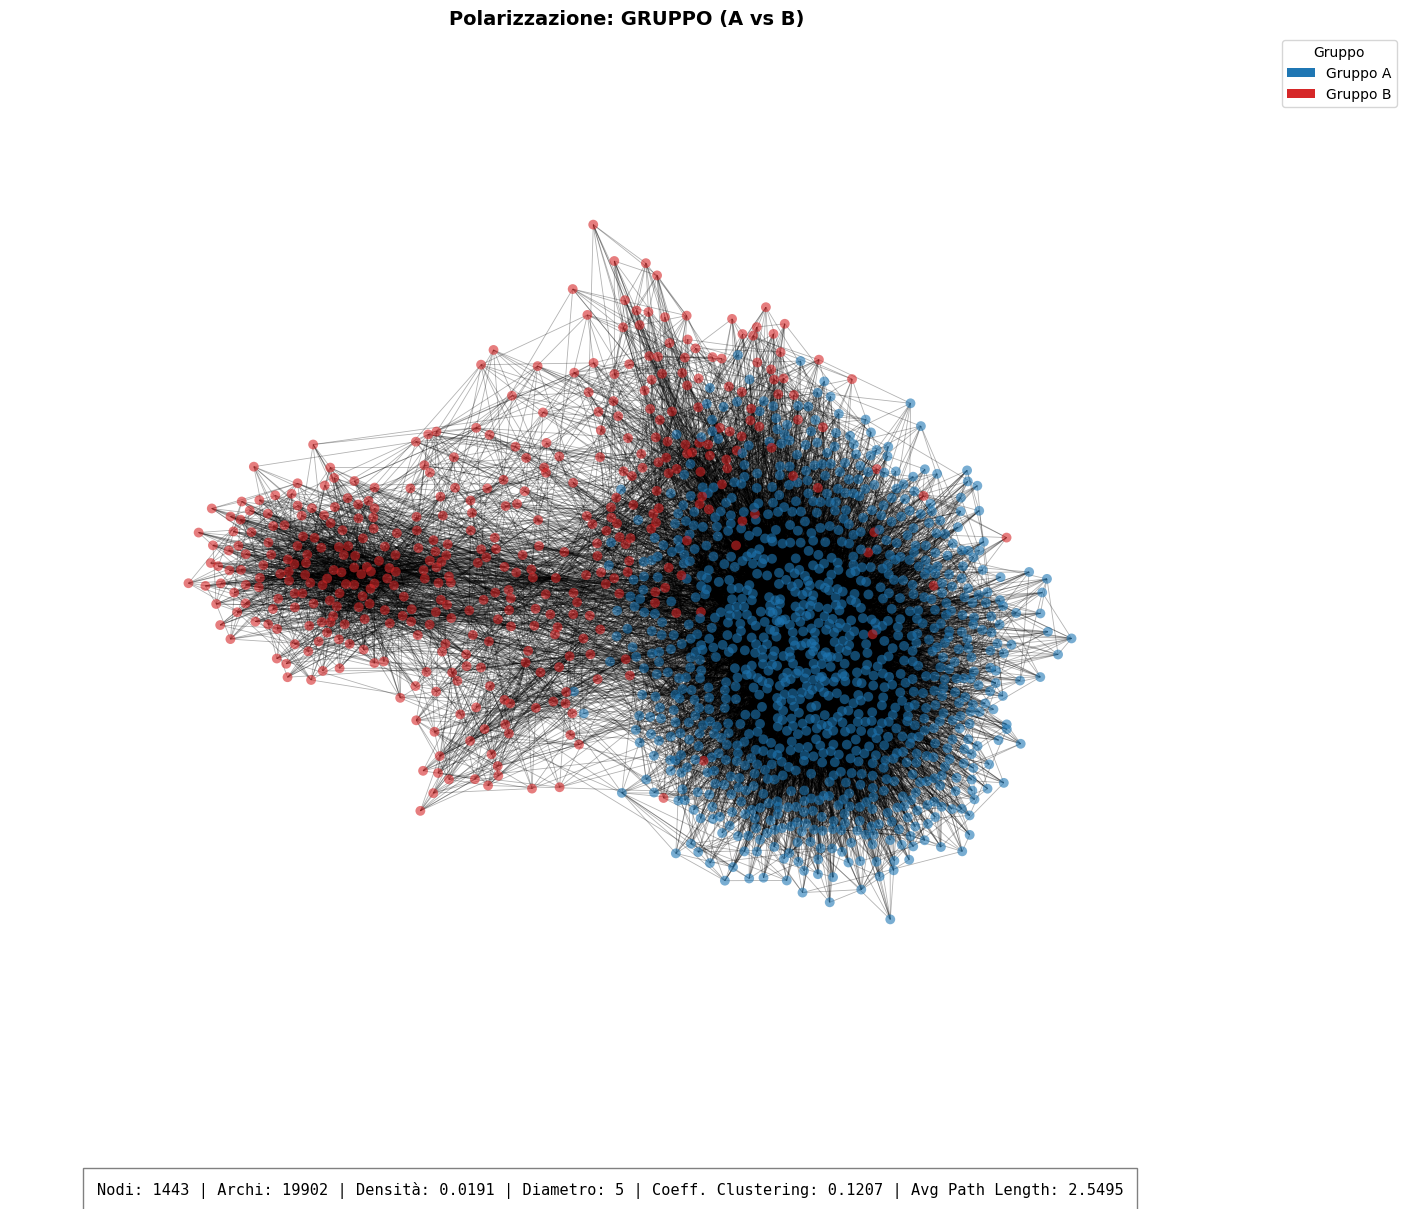

In [121]:
subgraph_kcore = subgraph_core(G, K_core=9
                               )

In [69]:
print_network_statistics(subgraph_kcore)

        STATISTICHE DEL NETWORK        
----------------------------------------
Numero di Nodi: 1044
Numero di Archi: 16189
Densità del Grafo: 0.029734813002575095
Grado Medio: 31.013409961685824
Clustering Medio: 0.22873742798113914
Diametro: 4
----------------------------------------


In [70]:
subgraphkcore_max = subgraph_core(G, K_core=max_coreness, plot=False)
communities_statistics(subgraphkcore_max)

(154, 1, 0.9935483870967742, 0.006451612903225823, 0.012819979188345506)

## Scatter plot (coreness vs ...)

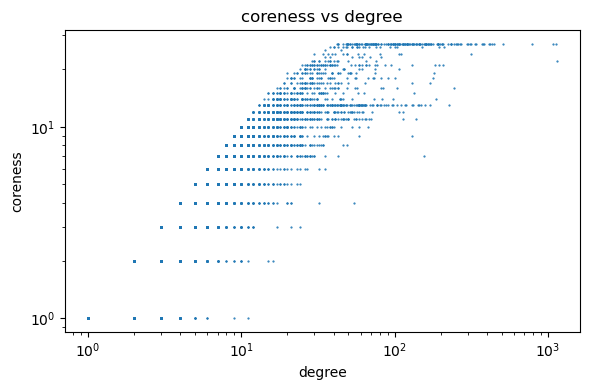

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'coreness vs degree'}, xlabel='degree', ylabel='coreness'>)

In [ ]:
# coreness vs degree
plot_metric_vs_metric_AB(G, 'degree', 'coreness', group='A')

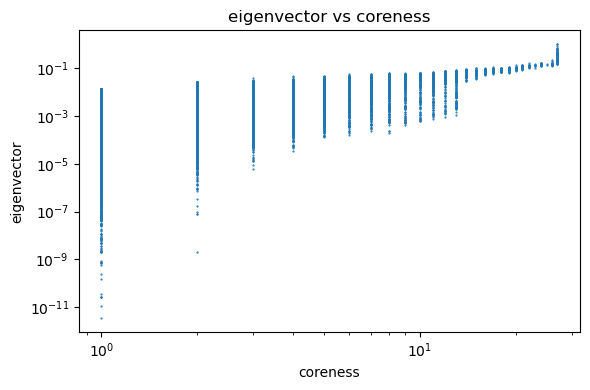

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'eigenvector vs coreness'}, xlabel='coreness', ylabel='eigenvector'>)

In [ ]:
# coreness vs eigenvector
plot_metric_vs_metric(G, 'coreness', 'eigenvector')

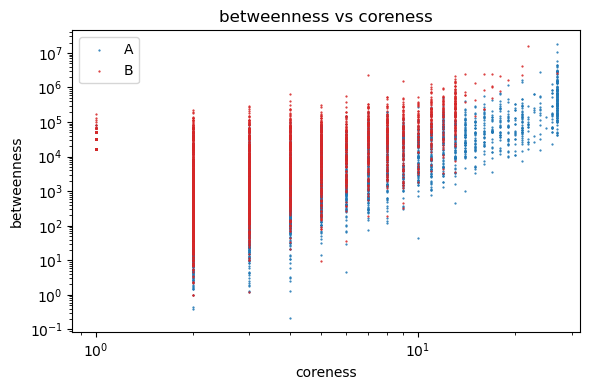

In [ ]:
# coreness vs betweenness
fig, ax = plt.subplots(figsize=FIGSIZE, sharex=True, layout='tight')
plot_metric_vs_metric_AB(G_A, 'coreness', 'betweenness', ax, group='A')
plot_metric_vs_metric_AB(G_B, 'coreness', 'betweenness', ax, group='B')


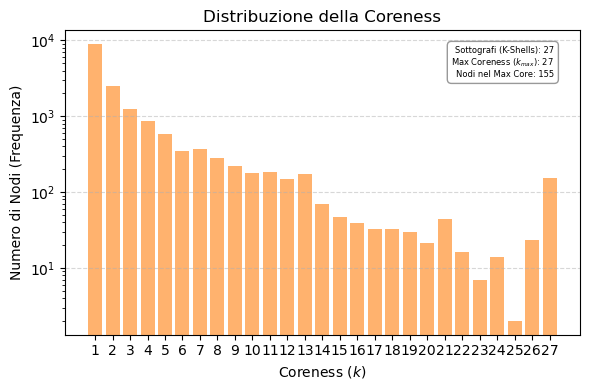

In [ ]:
from collections import Counter
# Conta le frequenze di ciascun livello di k
counts = Counter(G.vs['coreness'])
ks = sorted(counts.keys())
frequencies = [counts[k] for k in ks]

fig, ax = plt.subplots(figsize=FIGSIZE, sharex=True, layout='tight')

# Grafico a barre
ax.bar(ks, frequencies, color=cmap(1), alpha=0.6)

# Ottimizzazione assi e griglia
ax.set_xlabel("Coreness ($k$)")
ax.set_ylabel("Numero di Nodi (Frequenza)")
ax.set_title("Distribuzione della Coreness")

# Usa scala logaritmica sull'asse Y se la periferia schiaccia troppo il grafico
ax.set_yscale('log') 

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_xticks(ks if len(ks) < 30 else np.arange(min(ks), max(ks)+1, max(ks)//10))

# Box informativo con metriche chiave
info_text = f"Sottografi (K-Shells): {len(ks)}\nMax Coreness ($k_{{max}}$): {max(ks)}\nNodi nel Max Core: {counts[max(ks)]}"
ax.text(0.95, 0.95, info_text, transform=ax.transAxes, fontsize=6,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()

plt.show()

plt.close(fig)

Domanda: Gli hub hanno alta coreness?

# Spearman rank

In [33]:
from scipy.stats import spearmanr

metrics = ['degree', 'eigenvector', 'closeness', 'betweenness']
df = pd.DataFrame({m: G.vs[m] for m in metrics})

# --- Matrice di correlazione di Spearman ---
corr_matrix, p_matrix = spearmanr(df)
corr_df = pd.DataFrame(corr_matrix, index=metrics, columns=metrics)

print(corr_df.round(3))

             degree  eigenvector  closeness  betweenness
degree        1.000        0.549      0.596        0.943
eigenvector   0.549        1.000      0.979        0.470
closeness     0.596        0.979      1.000        0.522
betweenness   0.943        0.470      0.522        1.000


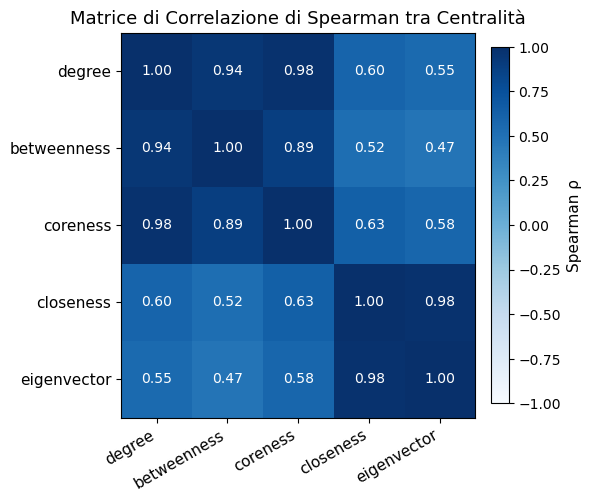

In [34]:
from scipy.stats import spearmanr
import matplotlib.colors as mcolors


# --- 2. Calcola le centralità ---
centralities = {
    'degree':      G.vs['degree'],
    'betweenness': G.vs['betweenness'],
    'coreness':    G.vs['coreness'],
    'closeness':   G.vs['closeness'],
    'eigenvector': G.vs['eigenvector'],
    
}

labels = list(centralities.keys())
n = len(labels)
data = np.array([centralities[k] for k in labels])  # shape (4, n_nodes)

# --- 3. Matrice di correlazione di Spearman ---
corr_matrix = np.ones((n, n))
pval_matrix = np.ones((n, n))

for i in range(n):
    for j in range(i + 1, n):
        r, p = spearmanr(data[i], data[j])
        corr_matrix[i, j] = r
        corr_matrix[j, i] = r
        pval_matrix[i, j] = p
        pval_matrix[j, i] = p

# --- 4. Plot heatmap con matplotlib puro ---
fig, ax = plt.subplots(figsize=(5, 5))

# Colormap divergente centrata su 0
vmin, vmax = -1, 1
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

im = ax.imshow(corr_matrix, cmap=CMAP_HEAT, norm=norm, aspect='auto')

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Spearman ρ", fontsize=11)

# Etichette assi
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
ax.set_title("Matrice di Correlazione di Spearman tra Centralità", fontsize=13)

low = corr_matrix.min() if vmin is None else vmin
high = corr_matrix.max() if vmax is None else vmax
threshold = (low + high) / 2.0 if high > low else high
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        value = corr_matrix[i, j]
        text_color = 'white' if value >= threshold else 'black'
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha='center',
            va='center',
            color=text_color,
        )
plt.savefig('correlation_heatmap.png')        
plt.show()

plt.close(fig)        

# Confronto con modelli nulli

In [9]:
n_nodi = G.vcount()
m_edges = G.ecount()

mean_degree = m_edges * 2 / n_nodi
print(f"La rete in analisi ha {n_nodi} nodi e {m_edges} edges")

# genero grafo con Erdos Renyi
G_er = ig.Graph.Erdos_Renyi(n=n_nodi, m=m_edges)
# genero grafo con Barabasi-Albert
G_ba = ig.Graph.Barabasi(n_nodi, max(1, round(mean_degree / 2)))

G_er.vs['degree'] = G_er.degree()
G_ba.vs['degree'] = G_ba.degree()


La rete in analisi ha 16639 nodi e 50605 edges


In [4]:
def plot_ccdf_random_model(G: ig.Graph | list[ig.Graph], metric: str='degree', log: bool=True, savefile='', title='', legend=None):
    
    if isinstance(G, ig.Graph):
        G = [G]
    if legend is None:
        legend = [str(i) for i in range(1,len(G)+1)]
        
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    for graph, color, label in zip(G, (cmap(0), cmap(1), cmap(2)), legend):
        values = np.array(graph.vs[metric])
        values = np.sort(values)[::-1]
        k_values, ccdf = compute_ccdf(values)
        ax[0].plot(k_values, ccdf, marker='o', markersize=1, linewidth=0.8, color = color, label=label)
        ax[0].set_xlabel(metric)
        ax[0].set_ylabel('ccdf')
        if log:
            ax[0].set_xscale('log')
            ax[0].set_yscale('log')
        ax[1].plot(np.arange(1,len(values)+1), values, marker='o', markersize=1, linewidth=0.8, color = color, label=label)
        ax[1].set_ylabel(metric)
        ax[1].set_xlabel('Rank')    
        

        if log:
            ax[1].set_xscale('log')
            ax[1].set_yscale('log')

    ax[0].legend(frameon=False, bbox_to_anchor=(0.99,0.9), loc='upper right')
    ax[1].legend(frameon=False, bbox_to_anchor=(0.99,0.9), loc='upper right')   
    
    if title:
        fig.suptitle(title)
    else:
        fig.suptitle(metric + ' complementary cumulative distribution')
    if savefile:
        plt.savefig(savefile)
    else:
        plt.show()

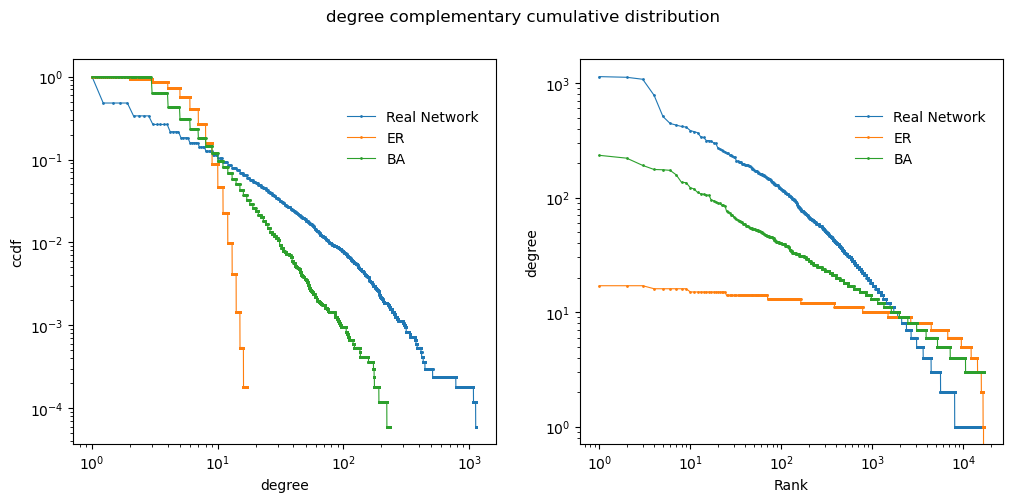

In [14]:
plot_ccdf_random_model([G, G_er, G_ba], metric='degree', legend=('Real Network', 'ER', 'BA'))

# Omofilia e Polarizzazione

## Degree correlation function
knn(k): media del grado medio dei vicini di un nodo con grado k

In [38]:
from scipy.stats import linregress

In [39]:
def compute_knn(G):
    knn_node, knn_degree = G.knn()
    k = []
    knn = []

    for k_val, val in enumerate(knn_degree):
        # Consideriamo solo i gradi esistenti nella rete (valori non nulli/NaN)

        if val > 0 and k_val >0 and not np.isnan(val):
            k.append(k_val)
            knn.append(val)
    return np.array(k), np.array(knn)

def plot_knn(G: ig.Graph | list[ig.Graph], legend=None):
    
    summary = []

    if isinstance(G, ig.Graph):
        G = [G]

    if legend is None:
        legend = [str(i) for i in range(1,len(G)+1)]    

    fig, ax = plt.subplots(figsize=FIGSIZE)

    
    for graph, color, label in zip(G, (color_group['A'], color_group['B']), legend):

        r = graph.assortativity_degree(directed=False) 
        k, knn = compute_knn(graph)
        slope, intercept, R, p, _ = linregress(np.log10(k), np.log10(knn))
        xline = np.linspace(k.min(), k.max(), 100)
        ax.plot(xline, 10**intercept * (xline**slope), linestyle='--', linewidth=1.6, label=f"r={slope:.2f}")
        


        ax.scatter(k, knn, s=1, color=color, label=label)
        ax.set_xscale('log')
        ax.set_yscale('log')  
        ax.set_xlabel("k")
        ax.set_ylabel("knn(k)")  
        ax.text(0.1, 0.1, ("Assortativa" if slope > 0 else "Disassortativa"),
            transform=ax.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))
        
        print(f"Grafo: {label}: r={r:.4f}, slope={slope:.4f}")
    
    fig.suptitle("Degree correlation function knn(k)")
    
    ax.legend()
    plt.savefig('knn_plot.png')
    plt.show()
    


Grafo: g: r=-0.1398, slope=-0.3280


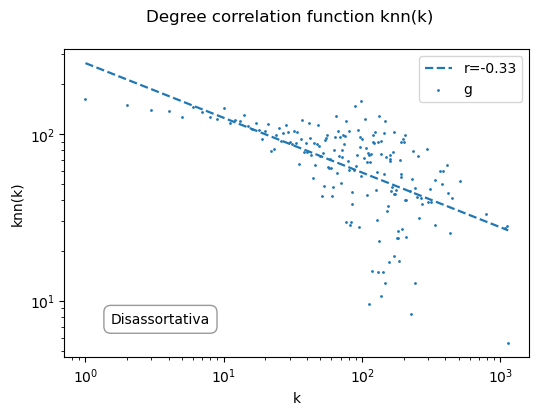

In [40]:
plot_knn(G, legend='global')

Grafo: A: r=-0.1961, slope=-0.3623
Grafo: B: r=-0.0988, slope=-0.4711


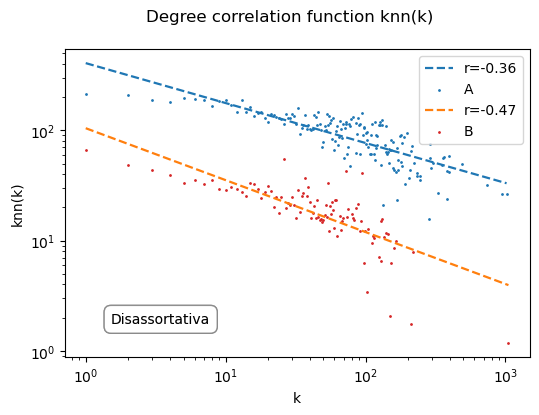

In [41]:
plot_knn([G_A, G_B], legend=['A','B'])

Invece di tagliare la rete, mantieni la rete intera, ma calcola la $k_{nn}$ condizionata.
Puoi plottare la $k_{nn}(k)$ classica, ma colorando o separando i punti nel plot in base al fatto che il nodo di partenza appartenga al core o alla periferia. Questo ti permette di vedere se la pendenza negativa è guidata principalmente dai nodi a basso grado (che puntano ad alto grado) o se anche i nodi ad alto grado evitano di parlarsi tra loro.

## Assortatività nominale

In [12]:
group_label = [1 if v == 'A' else 0 for v in G.vs['group']]
assortativita = G.assortativity_nominal(
    types=group_label,
    directed=False                
)
print(f"Assortatività nominale: {assortativita:.4f}")
if assortativita>0.7:
    print("-> Alta omofilia")

Assortatività nominale: 0.8038
-> Alta omofilia


Un risultato particolarmente interessante da cercare nel tuo caso: incrociare la matrice di mixing con la coreness. Puoi rifarlo calcolando la mixing matrix solo sui nodi con coreness alta (il core) e confrontarla con quella della periferia. Se il core è politicamente misto ma la periferia è segregata, hai una struttura di élite trasversale con basi separate — un pattern reale e pubblicabile.

In [12]:
group_label = np.array([1 if v == 'A' else 0 for v in G.vs['group']])

In [13]:
group_label

array([1, 1, 1, ..., 1, 0, 1], shape=(16639,))

In [125]:
def mixing_matrix(G: ig.Graph, 
                  partition: np.ndarray | None = None, 
                  normalized: bool = True):
    
    
    
    edgelist = G.get_edgelist()

    if partition is not None:
        
        q = 2
        M = np.zeros((q, q))
        labels = list(range(q))
        for u, v in edgelist:
            r, s = partition[u], partition[v]
            M[r, s] += 1
            if r != s:
                M[s, r] += 1
    
    # calcolo la matrice di mixing senza confrontarla con nessuna partizione 
    else:
        labels = sorted(set(G.vs['group'])) # [A, B]
        label_idx = {l: i for i, l in enumerate(labels)} # {'A': 0, 'B': 1}
        n = len(labels)
        M = np.zeros((n, n))

        for u, v in edgelist:
            r = label_idx[G.vs[u]['group']]
            s = label_idx[G.vs[v]['group']]
            if r == s:
                M[r, r] += 1
            else:
                M[r, s] += 1
                M[s, r] += 1    
    
    if normalized:
        M = M / M.sum()

    return M, labels


def plot_mixing_matrix(G, M, labels, title=''):

    
    fig, ax = plt.subplots(figsize=(5, 4))

    im = ax.imshow(M, cmap=CMAP_HEAT, vmin=0, vmax=M.max())
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=13)
    ax.set_yticklabels(labels, fontsize=13)
    ax.set_xlabel('Gruppo', fontsize=12)
    ax.set_ylabel('Gruppo', fontsize=12)
    ax.set_title('Mixing matrix' + title)

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f'{M[i,j]:.1f}',
                    ha='center', va='center',
                    color='white' if M[i,j] > M.max()*0.6 else 'black',
                    fontsize=10)

    plt.colorbar(im, ax=ax, label='Frazione di archi')
    plt.tight_layout()
    plt.show()

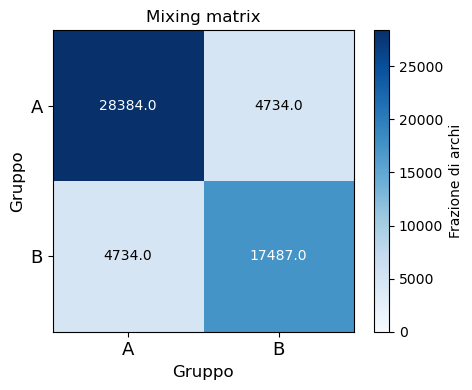

In [111]:
M, labels = mixing_matrix(G, normalized=False)
plot_mixing_matrix(G, M, labels)

si puo sequenziare in qualche modo la coreness? es. usando i percentili?

Se vuoi trovare il valore di coreness esatto in cui la rete smette di essere disassortativa e diventa una cricca coesa (se esiste), devi sequenziare l'analisi calcolando una metrica target (es. la densità o l'assortatività) per ogni singolo valore possibile di $k$.Plottando questa sequenza, cerchi il "punto di rottura".

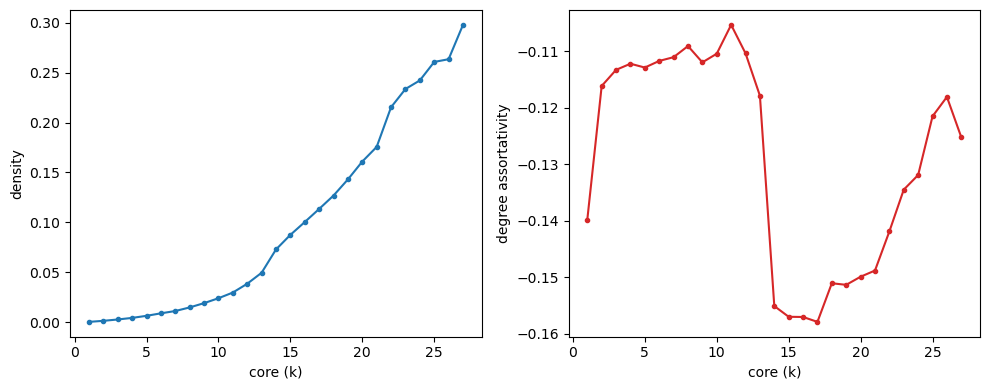

In [45]:
k_sequence = range(1, max_coreness + 1)
densities = []
assortativities = []

for k in k_sequence:
    subgraph = subgraph_core(G, k, plot=False)
    densities.append(subgraph.density()) # calcolo la densità del core k

    
    if len(subgraph.es) > 1:
        assortativities.append(subgraph.assortativity_degree()) # calcolo la densità del core k
    else:
        assortativities.append(None)

# Plot della sequenza
fig, ax = plt.subplots(1,2, figsize=(10,4),layout='tight')
ax[0].plot(k_sequence, densities, marker='o', markersize=3,color=cmap(0))
ax[0].set_xlabel('core (k)')
ax[0].set_ylabel('density')
ax[1].plot(k_sequence, assortativities, marker='o', markersize=3, color=cmap(3))
ax[1].set_xlabel('core (k)')
ax[1].set_ylabel('degree assortativity')

plt.show()

Da k=13 a k=14 la comunità B scompare quasi del tutto

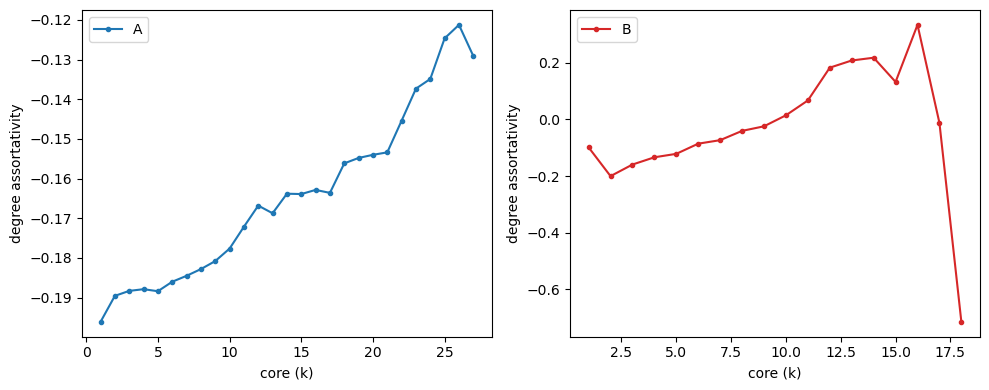

In [46]:
k_sequence = range(1, max_coreness + 1)
assortativities_A = []
assortativities_B = []

for k in k_sequence:
    subgraph_A = subgraph_core(G_A, k, plot=False)
    subgraph_B = subgraph_core(G_B, k, plot=False)
    
    if len(subgraph.es) > 1:
        assortativities_A.append(subgraph_A.assortativity_degree()) # calcolo la densità del core k
        assortativities_B.append(subgraph_B.assortativity_degree())
    else:
        assortativities_A.append(None)
        assortativities_B.append(None)

# Plot della sequenza
fig, ax = plt.subplots(1,2, figsize=(10,4),layout='tight')
ax[0].plot(k_sequence, assortativities_A, marker='o', markersize=3, color=color_group['A'], label='A')
ax[0].set_xlabel('core (k)')
ax[0].set_ylabel('degree assortativity')
ax[1].plot(k_sequence, assortativities_B, marker='o', markersize=3, color=color_group['B'], label='B')
ax[1].set_xlabel('core (k)')
ax[1].set_ylabel('degree assortativity')
ax[0].legend()
ax[1].legend()

plt.show()

## Shuffle delle label

In [4]:
def cross_type_fraction(G: ig.Graph, attr_map):
    cross = sum(1 for u, v in G.get_edgelist() if attr_map[u] != attr_map[v])
    return cross / G.ecount()


def permutation_test(G: ig.Graph, n_perm=2000):
    group_label = np.array([1 if v == 'A' else 0 for v in G.vs['group']]) 
    observed = cross_type_fraction(G, group_label)
    results_simulated = np.zeros(n_perm)
    
    for i in range(n_perm):
        np.random.shuffle(group_label)
        results_simulated[i]=cross_type_fraction(G, group_label)
        barra_avanzamento(i, n_perm)

    p_value = ( np.sum(results_simulated<=observed) + 1 ) / ( n_perm + 1 )   

    return observed, results_simulated, p_value

In [22]:
k_core = 10
subgraph = subgraph_core(G, K_core=k_core, plot=False)


In [23]:
n_A, n_B, p, q, baseline = communities_statistics(subgraph)

print(f"nodi di A: {n_A}\nnodi di B: {n_B}\nprobabilità di appartenere ad A: {p*100:.1f}%\nprobabilità di appartenere a B: {q*100:.1f}%\nbaseline={baseline}"
)

nodi di A: 898
nodi di B: 325
probabilità di appartenere ad A: 73.4%
probabilità di appartenere a B: 26.6%
baseline=0.390244489476369


In [63]:
# provo su un sottografo
observed, results, p_value = permutation_test(subgraph, 2000)

Avanzamento: |███████████████████████████████████████-| 100.0% completo

Text(0.5, 0.98, 'Permutation test for cross-type edge fraction with k=10')

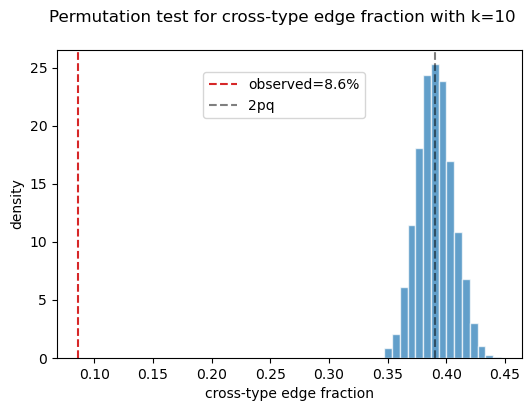

In [ ]:
bins = 15
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.axvline(observed, color=cmap(3), linestyle='--', label=f'observed={observed*100:.1f}%')
ax.axvline(baseline, color='black', linestyle='--', alpha=0.5, label=f'2pq={baseline:.2f}')
ax.hist(results, bins=bins, color=cmap(0), density=True, edgecolor='white', alpha=0.7)
ax.set_xlabel('cross-type edge fraction')
ax.set_ylabel('density')
ax.legend(frameon=True, bbox_to_anchor=(0.3,0.95), loc='upper left')
fig.suptitle(f"Permutation test for cross-type edge fraction with k={k_core}")



come vogliamo lo shuffle? che generatore random vogliamo usare?


## Configuration model

In [24]:
def ei_index(G: ig.Graph, attr_map):
    edge_type = [attr_map[u] == attr_map[v] for u, v in G.get_edgelist()]
    I = sum(edge_type)
    E = sum(map(lambda x: not x, edge_type))


    return (E - I)/(E + I)


In [6]:
n_A, n_B, p, q, baseline = communities_statistics(G)

print(f"nodi di A: {n_A}\nnodi di B: {n_B}\nprobabilità di appartenere ad A: {p*100:.1f}%\nprobabilità di appartenere a B: {q*100:.1f}%"
)

nodi di A: 7409
nodi di B: 9230
probabilità di appartenere ad A: 44.5%
probabilità di appartenere a B: 55.5%


In [26]:
def test_configuration_model(G: ig.Graph, n_perm=2000, with_ei_index=True):

    group_label = np.array([1 if v == 'A' else 0 for v in G.vs['group']])
    results_simulated = np.zeros(n_perm)
    G_shuffled = G.copy()

    # configuration con metrica cross
    if not with_ei_index: 

        observed = cross_type_fraction(G, group_label)
        
        for i in range(n_perm):
            
            ig.Graph.rewire(G_shuffled, n=G_shuffled.ecount()*10)
            results_simulated[i]=cross_type_fraction(G_shuffled, group_label)
            barra_avanzamento(i, n_perm)


    # configuration con ei-index    
    else:
        
        observed = ei_index(G, group_label)
        
        for i in range(n_perm):
            
            ig.Graph.rewire(G_shuffled, n=G_shuffled.ecount()*10)
            results_simulated[i]=ei_index(G_shuffled, group_label)
            barra_avanzamento(i, n_perm)

            
    p_value = ( np.sum(results_simulated<=observed) + 1 ) / ( n_perm + 1 )   

    return observed, results_simulated, p_value

In [37]:
observed, results_simulated, p_value = test_configuration_model(G, n_perm=1000, with_ei_index=True)

Avanzamento: |███████████████████████████████████████-| 99.9% completo

In [61]:
results_simulated.max()


np.float64(-0.02515561703388993)

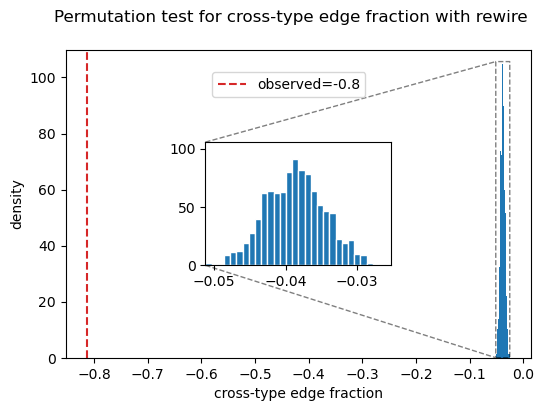

In [90]:
bins = 30
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.axvline(observed, color=cmap(3), linestyle='--', label=f'observed={observed:.1f}')
n= ax.hist(results_simulated, bins=bins, color=cmap(0), density=True)
ax.set_xlabel('cross-type edge fraction')
ax.set_ylabel('density')
ax.legend(frameon=True, bbox_to_anchor=(0.3,0.95), loc='upper left')
fig.suptitle(f"Permutation test for cross-type edge fraction with rewire")

# ho l'idea di fare uno zoom nel grafico
# Creazione degli assi interni (inset)
# I parametri indicano: [x_inizio, y2_inizio, larghezza, altezza] rispetto agli assi (da 0 a 1)
axins = ax.inset_axes([0.3, 0.3, 0.4, 0.4])

# Dati ingranditi nel riquadro
axins.hist(results_simulated, bins=bins, color=cmap(0), edgecolor='white')
axins.set_xlim(n[1].min(), n[1].max())  # Limiti della zona da zoomare
axins.set_ylim(0, n[0].max()+1) # Limiti della zona da zoomare

# Aggiunta automatica del rettangolo e delle linee di connessione
ax.indicate_inset_zoom(axins, edgecolor='black', linestyle='--')

# Stochastic block model (DCSBM)

Seguo le slide pg 68 ns 13 - community detection

1 - Inizializzazione

In [103]:
def log_likelihood_score(G: ig.Graph, partition: np.ndarray, q: int):

    degree = np.array(G.vs['degree'])
    
    # matrice di mixing -> conteggio degli archi tra gruppi (Lrs)
    L, _ = mixing_matrix(G, partition=partition, normalized=False)     

    # kr somma dei gradi di tutti i nodi nel gruppo r
    k = np.zeros(q)
    for i, r in enumerate(partition):
        k[r] += degree[i]

    # log-likelihood
    log_likelihood = 0
    for r in range(q):
        for s in range(q):
            if L[r, s] > 0 and k[r] > 0 and k[s] > 0:
                log_likelihood += L[r][s] * np.log( L[r][s] / (k[r] * k[s]) )

    return log_likelihood, L, k       
    


In [104]:

def count_edges_to_blocks(i: int, partition: np.ndarray, q: int,
                           adjacency: list) -> np.ndarray:
    """
    Conta quanti vicini del nodo i appartengono a ciascun blocco.
    m[t] = numero di archi di i verso il blocco t.
    """
    m = np.zeros(q, dtype=int)
    for nb in adjacency[i]: # scorro sui vicini del nodo i
        m[partition[nb]] += 1
    return m

In [105]:

def delta_log_likelihood(i: int, old_block: int, 
                         new_block: int,
                         L: np.ndarray,
                         k: np.ndarray,
                         m: np.ndarray,
                         degree: np.ndarray,
                         q: int) -> float:
    """
    Calcola ΔLL = LL_new - LL_old quando il nodo i si sposta da old_block a new_block.
    Aggiorna solo le righe/colonne r=old_block e s=new_block della matrice L.
 
    Parametri
    ---------
    m      : count_edges_to_blocks(i, partition, q, adjacency)
    degree : array dei gradi di tutti i nodi
    """
    r, s = old_block, new_block
    ki = degree[i]
 
    # --- Costruisci L' e k' localmente (solo righe r e s) ------------------
    L_new = L.copy() # copia della matrice di mixing
    # Aggiornamento archi interni
    L_new[r, r] -= m[r]
    L_new[s, s] += m[s]
    # Aggiornamento archi misti r-s
    L_new[r, s] += m[r] - m[s]
    L_new[s, r] = L_new[r, s]
    # Aggiornamento archi verso tutti gli altri blocchi t
    
    k_new = k.copy()
    k_new[r] -= ki
    k_new[s] += ki
 
    # --- Somma solo le righe r e s -----------------------------------------
    def row_contrib(L_mat, k_vec, row):
        total = 0.0
        for t in range(q):
            if L_mat[row, t] > 0 and k_vec[row] > 0 and k_vec[t] > 0:
                total += L_mat[row, t] * np.log(L_mat[row, t] /
                                                 (k_vec[row] * k_vec[t]))
        return total
 
    delta = 0.0
    for row in (r, s):
        delta += row_contrib(L_new, k_new, row) - row_contrib(L, k, row)
 
    return delta
 

In [113]:

def fit_sbm(G: ig.Graph, partition: np.ndarray, q: int, max_iter: int = 100, seed: int = None):
    """
    Fitta uno Stochastic Block Model seguendo l'algoritmo greedy:
      1. Inizializzazione casuale
      2. Per ogni nodo in ordine random: sposta nel blocco che massimizza Δℓ
      3. Ripeti finché nessun miglioramento
 
    Returns
    -------
    partition     : np.ndarray  assegnazione finale dei nodi ai blocchi
    log_lik       : float       log-likelihood finale
    """
    if seed is not None:
        np.random.seed(seed)
 
    n = G.vcount()
    degree = np.array(G.vs['degree'])
 
    # Lista di adiacenza come array numpy 
    adjacency = [np.array(G.neighbors(i)) for i in range(n)]
 
    # --- 1. Inizializzazione ------------------------------------------------
    
    ll, L, k = log_likelihood_score(G, partition, q)
    print(f"[init] log-likelihood = {ll:.4f}")
 
    # --- 2. Ottimizzazione --------------------------------------------------
    for iteration in range(max_iter):
        improved = False
        order = np.random.permutation(n)
 
        for i in order:
            old_block = partition[i]
 
            # Conta gli archi di i verso ogni blocco  (O(deg(i)))
            m = count_edges_to_blocks(i, partition, q, adjacency)
 
            best_delta = 0.0
            best_block = old_block
 
            for new_block in range(q):
                if new_block == old_block:
                    continue
 
                # FIX CRITICO: calcolo incrementale, nessuna copia di partition
                d = delta_log_likelihood(i, old_block, new_block,
                                         L, k, m, degree, q)
                if d > best_delta:
                    best_delta = d
                    best_block = new_block
 
            # Applica lo spostamento solo se c'è un miglioramento reale
            if best_block != old_block:
                # Aggiorna L e k in-place  (O(q))
                r, s = old_block, best_block
                ki = degree[i]
                L[r, r] -= m[r]
                L[s, s] += m[s]
                L[r, s] = L[s, r] = L[r, s] + m[r] - m[s]
                
                k[r] -= ki
                k[s] += ki
                partition[i] = best_block      # FIX: aggiorna solo dopo la scelta
                improved = True
 
        ll_new, _, _ = log_likelihood_score(G, partition, q)
        print(f"[iter {iteration+1}] log-likelihood = {ll_new:.4f}  "
              f"(Δ = {ll_new - ll:+.4f})")
        ll = ll_new
 
        if not improved:
            print(f"Convergenza raggiunta all'iterazione {iteration+1}.")
            break
 
    return partition, ll
 

In [114]:
K = 2

partition = np.random.randint(0, K, size=n)
partition, final_ll = fit_sbm(G, partition=partition, q=K, max_iter=50, seed=42)
print(f"\nPartizione finale: {partition.tolist()}")
print(f"Log-likelihood finale: {final_ll:.4f}")

[init] log-likelihood = -889930.1241
[iter 1] log-likelihood = -717081.5551  (Δ = +172848.5689)
[iter 2] log-likelihood = -642434.1833  (Δ = +74647.3718)
[iter 3] log-likelihood = -630507.6608  (Δ = +11926.5225)
[iter 4] log-likelihood = -628290.4553  (Δ = +2217.2055)
[iter 5] log-likelihood = -628021.9840  (Δ = +268.4713)
[iter 6] log-likelihood = -627959.5273  (Δ = +62.4567)
[iter 7] log-likelihood = -627959.5273  (Δ = +0.0000)
Convergenza raggiunta all'iterazione 7.

Partizione finale: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [115]:
def multiple_restart(G: ig.Graph, K: int = 2, n_restarts: int = 10):
    
    n = G.vcount()
    best_ll = -np.inf
    best_partition = None
    
    for restart in range(n_restarts):
        print(f"\n--- Restart {restart+1}/{n_restarts} ---")
        
        partition = np.random.randint(0, K, size=n)
        partition, ll = fit_sbm(G, partition=partition, q=K, max_iter=50, seed=42)
        
        print(f"  log-likelihood finale: {ll:.4f}")
        
        if ll > best_ll:
            best_ll = ll
            best_partition = partition.copy()
    
    print(f"\n=== Miglior log-likelihood: {best_ll:.4f} ===")
    return best_partition, best_ll

In [116]:
final_partition, best_log_likelihood = multiple_restart(G, n_restarts=50)


--- Restart 1/50 ---
[init] log-likelihood = -891641.9889
[iter 1] log-likelihood = -728038.9536  (Δ = +163603.0353)
[iter 2] log-likelihood = -668784.6960  (Δ = +59254.2576)
[iter 3] log-likelihood = -657307.9296  (Δ = +11476.7664)
[iter 4] log-likelihood = -654355.9403  (Δ = +2951.9893)
[iter 5] log-likelihood = -652143.7625  (Δ = +2212.1778)
[iter 6] log-likelihood = -651494.1974  (Δ = +649.5651)
[iter 7] log-likelihood = -651328.3825  (Δ = +165.8149)
[iter 8] log-likelihood = -650930.4478  (Δ = +397.9347)
[iter 9] log-likelihood = -650803.1446  (Δ = +127.3032)
[iter 10] log-likelihood = -650710.3886  (Δ = +92.7560)
[iter 11] log-likelihood = -650672.4646  (Δ = +37.9240)
[iter 12] log-likelihood = -650571.9993  (Δ = +100.4654)
[iter 13] log-likelihood = -650571.9993  (Δ = +0.0000)
Convergenza raggiunta all'iterazione 13.
  log-likelihood finale: -650571.9993

--- Restart 2/50 ---
[init] log-likelihood = -893408.7870
[iter 1] log-likelihood = -725790.8299  (Δ = +167617.9571)
[iter 2

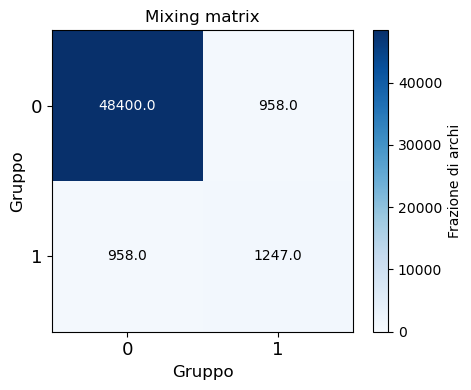

In [117]:
M, labels = mixing_matrix(G, partition=final_partition, normalized=False)
plot_mixing_matrix(G, M, labels)

## provo su subgraph con k = 11 

In [122]:
final_partition_kcore, best_log_likelihood_kcore = multiple_restart(subgraph_kcore, n_restarts=50)


--- Restart 1/50 ---
[init] log-likelihood = -351109.3963
[iter 1] log-likelihood = -277106.5383  (Δ = +74002.8580)
[iter 2] log-likelihood = -243180.5929  (Δ = +33925.9455)
[iter 3] log-likelihood = -242818.8643  (Δ = +361.7285)
[iter 4] log-likelihood = -242818.8643  (Δ = +0.0000)
Convergenza raggiunta all'iterazione 4.
  log-likelihood finale: -242818.8643

--- Restart 2/50 ---
[init] log-likelihood = -351009.7043
[iter 1] log-likelihood = -283154.5440  (Δ = +67855.1604)
[iter 2] log-likelihood = -250426.7547  (Δ = +32727.7893)
[iter 3] log-likelihood = -248240.5706  (Δ = +2186.1841)
[iter 4] log-likelihood = -247971.3042  (Δ = +269.2664)
[iter 5] log-likelihood = -247887.5880  (Δ = +83.7161)
[iter 6] log-likelihood = -247887.5880  (Δ = +0.0000)
Convergenza raggiunta all'iterazione 6.
  log-likelihood finale: -247887.5880

--- Restart 3/50 ---
[init] log-likelihood = -350717.7225
[iter 1] log-likelihood = -279992.0275  (Δ = +70725.6949)
[iter 2] log-likelihood = -243016.4447  (Δ = 

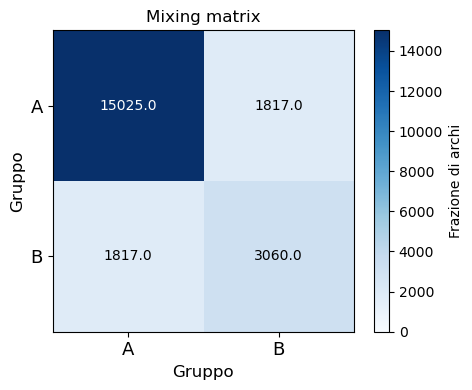

In [128]:
M_real, labels_real = mixing_matrix(subgraph_kcore, normalized=False)
plot_mixing_matrix(subgraph_kcore, M_real, labels_real)

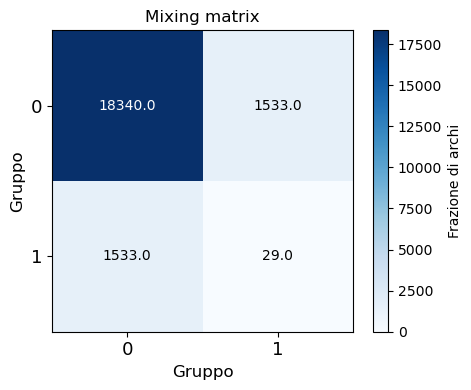

In [129]:
M, labels = mixing_matrix(subgraph_kcore, partition=final_partition, normalized=False)
plot_mixing_matrix(subgraph_kcore, M, labels)

#### cose 

In [51]:
q = 2 # numero di gruppi
N = G.vcount() # numero di nodi

# inizio con un'assegnazione random dei nodi a q gruppi
partition = np.random.randint(0, q, size=N)

# calcolo il log-likelihood score iniziale
ll_score, _, _  = log_likelihood_score(G, partition=partition, q=q) 


In [52]:
# lista di adiacenza come array numpy per velocità
adjacency = [np.array(G.neighbors(i)) for i in range(N)]

In [37]:
partition, ll_score

(array([1, 0, 0, ..., 0, 0, 0], shape=(16639,), dtype=int32),
 np.float64(-1406258.7788542921))

2 - Ottimizzazione

Per ogni nodo, lo muovo in ogni possibile gruppo e valuto la variazione di likelihood

In [ ]:
def optimize_partition(G: ig.Graph, partition: np.ndarray,
                       K: int, max_iter: int = 50) -> np.ndarray:
    """
    Greedy node-moving: sposta ogni nodo nel blocco
    che massimizza il guadagno di log-likelihood.
    Converge quando nessuno spostamento migliora.
    """
    n = G.vcount()
    degree = np.array(G.degree(), dtype=float)

    # lista di adiacenza come array numpy per velocità
    # ogni array è la lista di vicini di un nodo
    adjacency = [np.array(G.neighbors(i)) for i in range(n)]
    newpartition = partition

    # vettore e: somma gradi per blocco
    _, _, e = log_likelihood_score(G, partition=partition, q=K)
    
    for iteration in range(max_iter):
        improved = False
        order = np.random.permutation(n)

        for i in order: # per ogni nodo in modo random
            old_block = partition[i] # A o B
            best_block = old_block
            best_delta = 0.0
            
            for k in range(K):
                if k == old_block: 
                    continue 
                newpartition[i] = k
                old_ll, _, _ = log_likelihood_score(G, partition=partition, q=K)
                new_ll, _, _ = log_likelihood_score(G, partition=newpartition, q=K)
                d = new_ll - old_ll
                if d > best_delta:
                    best_delta = d
                    best_block = k

            if best_block != old_block:
                # applica lo spostamento
                e[old_block] -= degree[i]
                e[new_block] += degree[i]  
                partition[i] = best_block
                improved = True

        if not improved:
            break

    return partition

In [ ]:
n = G.vcount()
partition = np.random.randint(0, q, size=n)
print("numero di nodi=",n)
degree = np.array(G.degree(), dtype=float)
K = 2
max_iter = 1
# lista di adiacenza come array numpy per velocità
# ogni array è la lista di vicini di un nodo
adjacency = [np.array(G.neighbors(i)) for i in range(n)]
newpartition = partition.copy()
count = 0

# vettore e: somma gradi per blocco
_, _, e = log_likelihood_score(G, partition=partition, q=K)

for iteration in range(max_iter):
    improved = False
    order = np.random.permutation(n)

    for i in order: # per ogni nodo in modo random
        old_block = partition[i] # A o B
        print(f"gruppo iniziale del nodo {i} = {old_block}")
        new_block = old_block
        best_delta = 0.0
        
        for k in range(K):
            if k == old_block: 
                continue 
            newpartition[i] = k # valuto la nuova partizione
            print(f"newpartition[{i}]={newpartition[i]}")
            old_ll, _, _ = log_likelihood_score(G, partition=partition, q=K)
            new_ll, _, _ = log_likelihood_score(G, partition=newpartition, q=K)
            d = new_ll - old_ll # calcolo il gain di log-likelihood
            print("delta_ll=",d)
            if d > best_delta:
                best_delta = d
                new_block = k

        if new_block != old_block:
            # applica lo spostamento
            e[old_block] -= degree[i]
            e[new_block] += degree[i]  
            partition[i] = new_block
            improved = True
            print('spostato nodo ', i)
            count += 1

    if not improved:
        break

numero di nodi= 16639
gruppo iniziale del nodo 14447 = 0
newpartition[14447]=1
delta_ll= 0.0
gruppo iniziale del nodo 2781 = 0
newpartition[2781]=1
delta_ll= 0.0
gruppo iniziale del nodo 2893 = 0
newpartition[2893]=1
delta_ll= 0.0
gruppo iniziale del nodo 11748 = 1
newpartition[11748]=0
delta_ll= 0.0
gruppo iniziale del nodo 3389 = 1
newpartition[3389]=0
delta_ll= 0.0
gruppo iniziale del nodo 4999 = 0
newpartition[4999]=1
delta_ll= 0.0
gruppo iniziale del nodo 3356 = 1
newpartition[3356]=0
delta_ll= 0.0
gruppo iniziale del nodo 1990 = 0
newpartition[1990]=1
delta_ll= 0.0
gruppo iniziale del nodo 4452 = 0
newpartition[4452]=1
delta_ll= 0.0
gruppo iniziale del nodo 10379 = 1
newpartition[10379]=0
delta_ll= 0.0
gruppo iniziale del nodo 13539 = 0
newpartition[13539]=1
delta_ll= 0.0
gruppo iniziale del nodo 12539 = 0
newpartition[12539]=1
delta_ll= 0.0
gruppo iniziale del nodo 806 = 1
newpartition[806]=0
delta_ll= 0.0
gruppo iniziale del nodo 4757 = 1
newpartition[4757]=0
delta_ll= 0.0
grup

KeyboardInterrupt: 

In [ ]:
count

In [ ]:
def delta_ll(neighbors_i: np.ndarray, partition: np.ndarray,
             degree: np.ndarray, e: np.ndarray,
             i: int, old_block: int, new_block: int, K: int) -> float:
    """
    Variazione di log-likelihood quando sposti il nodo i
    da old_block a new_block. Evita di ricalcolare tutto.
    """
    # archi di i verso ogni blocco
    m_i = np.zeros(K)
    for j in neighbors_i:
        m_i[partition[j]] += 1

    # contributo attuale
    ll_before = 0.0
    for k in range(K):
        if m_i[k] > 0 and e[old_block] > 0 and e[k] > 0:
            ll_before += m_i[k] * np.log(m_i[k] / (e[old_block] * e[k]))

    # aggiorna e temporaneamente
    e[old_block] -= degree[i]
    e[new_block] += degree[i]

    # contributo dopo lo spostamento
    ll_after = 0.0
    for k in range(K):
        if m_i[k] > 0 and e[new_block] > 0 and e[k] > 0:
            ll_after += m_i[k] * np.log(m_i[k] / (e[new_block] * e[k]))

    # ripristina e
    e[old_block] += degree[i]
    e[new_block] -= degree[i]

    return ll_after - ll_before

In [ ]:
# creo la matrice 
def compute_initial_counts(g, z, B):
    """Calcola la matrice degli archi E e i volumi dei blocchi iniziale."""
    E = np.zeros((B, B))
    degrees = np.array(g.degree())
    kappa = np.zeros(B)

    for r in range(B):
        kappa[r] = np.sum(degrees[z == r])

    adj = g.get_adjacency_sparse()
    rows, cols = adj.nonzero()
    for u, v in zip(rows, cols):
        E[z[u], z[v]] += 1

    return E, kappa


def calculate_dcsbm_likelihood_from_counts(E, kappa, m):
    """Calcola la log-likelihood totale partendo dalle matrici di conteggio."""
    log_lik = 0.0
    B = E.shape[0]
    for r in range(B):
        for s in range(B):
            if E[r, s] > 0 and kappa[r] > 0 and kappa[s] > 0:
                expected = (kappa[r] * kappa[s]) / (2 * m)
                log_lik += E[r, s] * np.log(E[r, s] / expected)
    return log_lik / 2


def fit_dcsbm_greedy(g, q=2, max_iter=10):
    """Fitta un DCSBM seguendo la procedura esatta della slide."""
    N = g.vcount()
    M = g.ecount()

    # 1. INITIALIZATION: Start with a random assignment
    z = np.random.randint(0, q, size=N)
    E, kappa = compute_initial_counts(g, z, q)
    current_lik = calculate_dcsbm_likelihood_from_counts(E, kappa, M)

    for iteration in range(max_iter):
        improved = False
        # For each node in random order
        nodes_order = list(range(N))
        random.shuffle(nodes_order)

        for u in nodes_order:
            current_group = z[u]
            u_degree = g.degree(u)
            neighbors = g.neighbors(u)

            # Calcoliamo i passaggi del nodo u verso i vari blocchi
            k_u_to_block = np.zeros(q)
            for v in neighbors:
                k_u_to_block[z[v]] += 1

            best_move_lik = current_lik
            best_group = current_group

            # Temporarily move to each possible group
            for target_group in range(q):
                if target_group == current_group:
                    continue

                # Aggiornamento locale ipotetico di E e kappa
                E_next = E.copy()
                kappa_next = kappa.copy()

                # Rimuovi u dal gruppo corrente
                kappa_next[current_group] -= u_degree
                for r in range(q):
                    E_next[current_group, r] -= k_u_to_block[r]
                    E_next[r, current_group] -= k_u_to_block[r]

                # Aggiungi u al gruppo target
                kappa_next[target_group] += u_degree
                for r in range(q):
                    E_next[target_group, r] += k_u_to_block[r]
                    E_next[r, target_group] += k_u_to_block[r]

                # Ricalcola la log-likelihood potenziale
                potential_lik = calculate_dcsbm_likelihood_from_counts(
                    E_next, kappa_next, M
                )

                if potential_lik > best_move_lik:
                    best_move_lik = potential_lik
                    best_group = target_group

            # Place the node in the group that gives highest improvement
            if best_group != current_group:
                # Applica lo spostamento definitivo
                kappa[current_group] -= u_degree
                kappa[best_group] += u_degree
                for r in range(q):
                    E[current_group, r] -= k_u_to_block[r]
                    E[r, current_group] -= k_u_to_block[r]
                    E[best_group, r] += k_u_to_block[r]
                    E[r, best_group] += k_u_to_block[r]

                z[u] = best_group
                current_lik = best_move_lik
                improved = True

        print(f"Iterazione {iteration+1} - Log-Likelihood: {current_lik:.4f}")

        # Repeat until no further improvement is possible
        if not improved:
            break

    return z, current_lik


# 3. MULTIPLE RESTARTS
def run_dcsbm_with_restarts(g, q=2, n_restarts=5):
    """Esegue l'algoritmo più volte con diverse condizioni iniziali."""
    best_overall_lik = -np.inf
    best_overall_partition = None

    for i in range(n_restarts):
        print(f"\n--- RESTART {i+1}/{n_restarts} ---")
        partition, final_lik = fit_dcsbm_greedy(g, q=q)

        # Select the partition with the highest overall likelihood
        if final_lik > best_overall_lik:
            best_overall_lik = final_lik
            best_overall_partition = partition.copy()

    return best_overall_partition, best_overall_lik